# Alzheimer's Disease Brain MRI Segmentation
## VGG19 + UNet | OASIS disc1 + disc2
Full pipeline: data loading → preprocessing → model training → metrics → visualizations

**Note:** EarlyStopping disabled — model trains for the full configured epochs as instructed.

## 1. Import Libraries

In [2]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    concatenate, BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

2026-06-18 12:19:06.360446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781785146.573816      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781785146.642219      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781785147.158558      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781785147.158604      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781785147.158611      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [3]:
# ─── Paths ────────────────────────────────────────────────────────────────────
ROOTS = [
    '/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1',
    '/kaggle/input/datasets/maheswarimudadla/disc2-oasiss1/disc2',
]

PROCESSED_DIR   = 'oasis_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15

print('Config set ✓')

Config set ✓


## 3. Load & Preprocess OASIS Data (disc1 + disc2)
OASIS stores brain volumes as Analyze `.img/.hdr` pairs. We slice along the coronal axis and save each 2-D slice as a PNG.

In [4]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')

Directories ready ✓


In [5]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices(subject_dir, img_out, mask_out, step=2):
    """
    For one OASIS subject directory, find the T88 masked brain volume
    and the FSL_SEG tissue mask, then save every `step`-th coronal slice.
    Returns number of slices saved.
    """
    subject_name = os.path.basename(subject_dir)
    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'MPRAGE', 'T88_111')
    fsl_dir = os.path.join(subject_dir, 'FSL_SEG')

    if not os.path.isdir(t88_dir) or not os.path.isdir(fsl_dir):
        return 0

    brain_img_path = None
    for f in os.listdir(t88_dir):
        if f.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, f)
            break

    seg_img_path = None
    for f in os.listdir(fsl_dir):
        if f.endswith('fseg.img'):
            seg_img_path = os.path.join(fsl_dir, f)
            break

    if brain_img_path is None or seg_img_path is None:
        return 0

    brain_vol = np.squeeze(nib.load(brain_img_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_img_path).get_fdata())

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f"{subject_name}_sl{i:03d}.png"
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


# ─── Clear old slices (fresh run) ──────────────────────────────────────────────
for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# ─── Gather subjects from both discs ───────────────────────────────────────────
subject_dirs = []
for root in ROOTS:
    if os.path.exists(root):
        dirs = [
            os.path.join(root, d)
            for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and d.startswith('OAS')
        ]
        subject_dirs += dirs
        print(f'{root} → {len(dirs)} subjects')

print(f'\nTotal subjects: {len(subject_dirs)}')

# ─── Extract ────────────────────────────────────────────────────────────────────
total_slices = 0
for subj in tqdm(subject_dirs, desc='Extracting slices'):
    total_slices += extract_slices(subj, IMAGE_FOLDER, MASK_FOLDER)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')

/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1 → 39 subjects
/kaggle/input/datasets/maheswarimudadla/disc2-oasiss1/disc2 → 38 subjects

Total subjects: 77


Extracting slices:   0%|          | 0/77 [00:00<?, ?it/s]


Total slices extracted : 6622
Images saved           : 6622
Masks  saved           : 6622


## 4. Data Visualisation

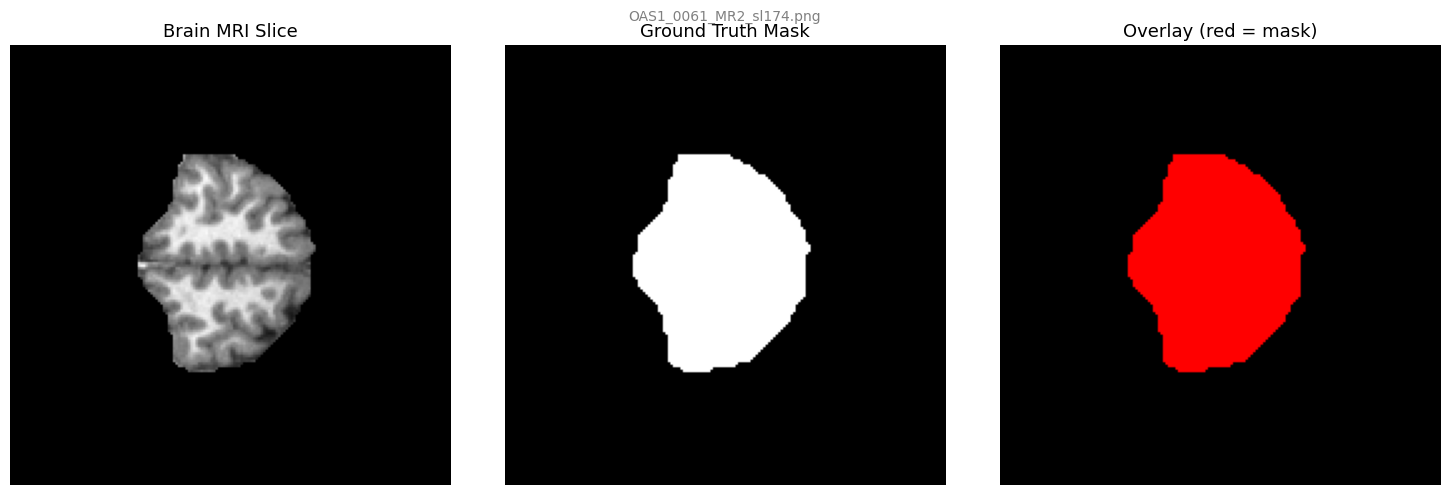

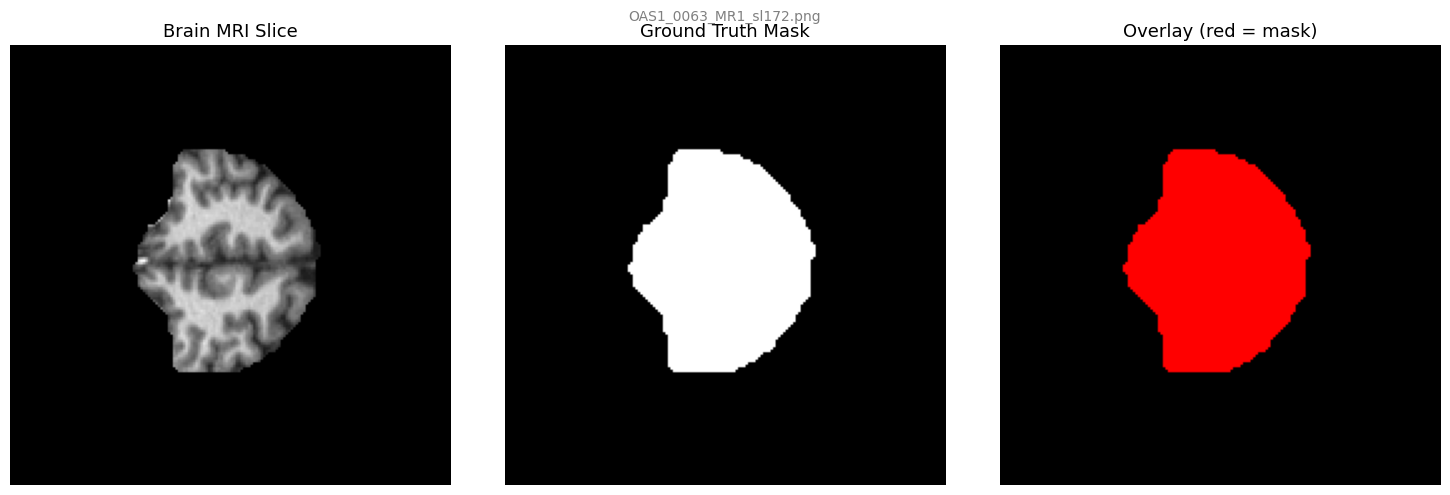

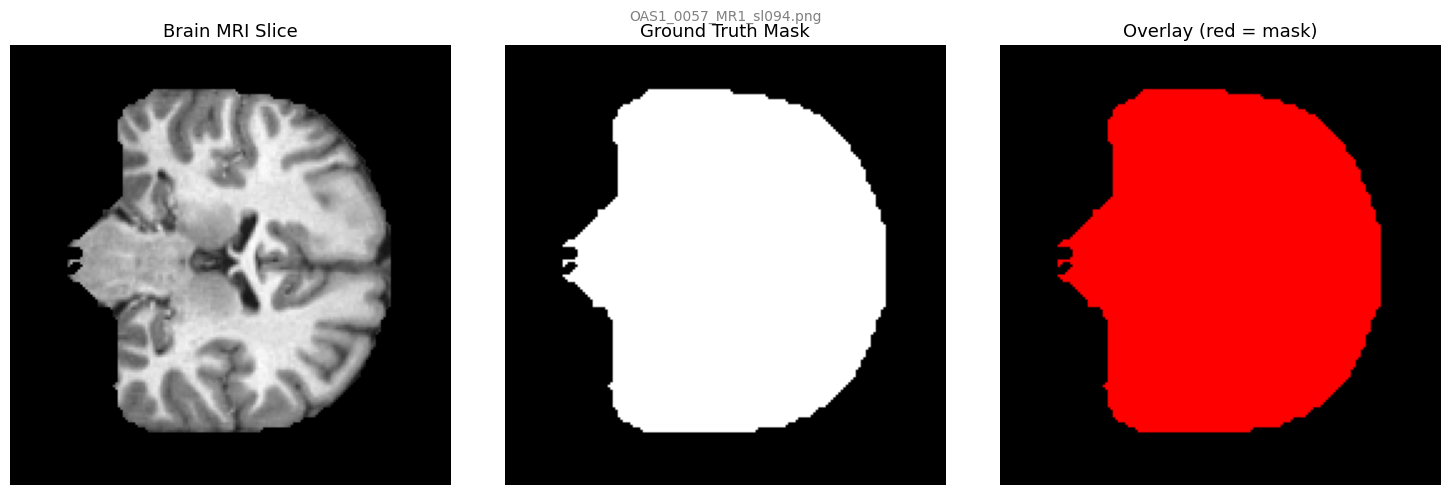

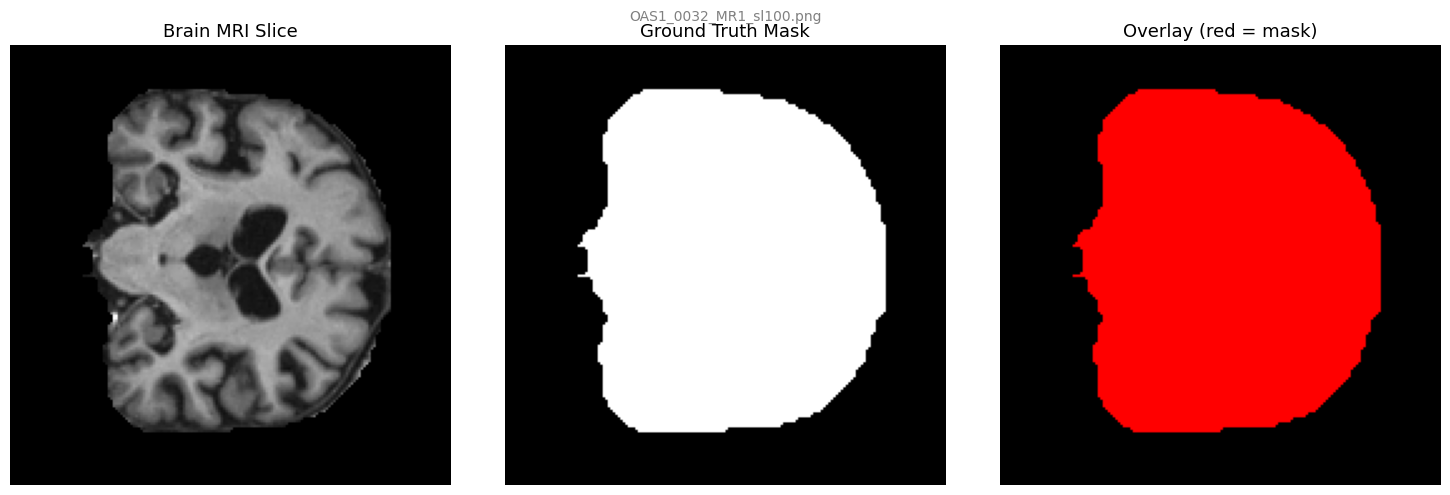

In [6]:
def visualize_sample(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask > 127, 0] = 255
    overlay[mask > 127, 1] = 0
    overlay[mask > 127, 2] = 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img,     cmap='gray');  axes[0].set_title('Brain MRI Slice',      fontsize=13)
    axes[1].imshow(mask,    cmap='gray');  axes[1].set_title('Ground Truth Mask',    fontsize=13)
    axes[2].imshow(overlay);               axes[2].set_title('Overlay (red = mask)', fontsize=13)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [7]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 5628  |  Test: 994


  0%|          | 0/5628 [00:00<?, ?it/s]

  0%|          | 0/994 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline

In [8]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1781785195.038973      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 1)


## 7. Model — VGG19 Encoder + UNet Decoder
**Key difference vs VGG16-UNet:** VGG19 has 3 conv layers per block in blocks 3-5 (vs 2 for VGG16) → deeper feature extraction, ~20M params in the base vs ~14.7M for VGG16. Skip connections are taken from the last conv layer of each block, same decoder pattern as the VGG16-UNet baseline so results are directly comparable.

In [9]:
def conv_block(x, filters, name_prefix):
    """Two Conv2D + BN + ReLU layers."""
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x


def decoder_block(x, skip, filters, name_prefix):
    """Upsample → concatenate skip → conv_block."""
    x = UpSampling2D((2, 2), name=f'{name_prefix}_up')(x)
    x = concatenate([x, skip], name=f'{name_prefix}_cat')
    x = Dropout(0.2, name=f'{name_prefix}_drop')(x)
    x = conv_block(x, filters, name_prefix)
    return x


def build_vgg19_unet(input_shape=(224, 224, 3), freeze_encoder=True):
    """
    VGG19 encoder (ImageNet weights) + symmetric UNet decoder.
    Skip connections taken from VGG19's last conv layer in each block.

    VGG19 block structure (vs VGG16):
      block1: conv1, conv2          (same as VGG16)
      block2: conv1, conv2          (same as VGG16)
      block3: conv1, conv2, conv3, conv4   (VGG16 has only conv1-conv3)
      block4: conv1, conv2, conv3, conv4   (VGG16 has only conv1-conv3)
      block5: conv1, conv2, conv3, conv4   (VGG16 has only conv1-conv3)
    """
    inputs = Input(shape=input_shape, name='input')

    # ── Encoder (VGG19) ────────────────────────────────────────────────────────
    base = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False

    # Skip connections at progressively deeper resolutions — last conv of each block
    s1 = base.get_layer('block1_conv2').output   # 224×224,  64 ch
    s2 = base.get_layer('block2_conv2').output   # 112×112, 128 ch
    s3 = base.get_layer('block3_conv4').output   #  56×56,  256 ch  (conv4, not conv3)
    s4 = base.get_layer('block4_conv4').output   #  28×28,  512 ch  (conv4, not conv3)

    # Bottleneck
    b  = base.get_layer('block5_conv4').output   #  14×14,  512 ch  (conv4, not conv3)

    # ── Decoder ────────────────────────────────────────────────────────────────
    d4 = decoder_block(b,  s4, 512, 'dec4')      #  28×28
    d3 = decoder_block(d4, s3, 256, 'dec3')      #  56×56
    d2 = decoder_block(d3, s2, 128, 'dec2')      # 112×112
    d1 = decoder_block(d2, s1,  64, 'dec1')      # 224×224

    # ── Output ─────────────────────────────────────────────────────────────────
    output = Conv2D(1, (1, 1), activation='sigmoid', name='output')(d1)

    model = Model(inputs=inputs, outputs=output, name='VGG19_UNet')
    return model


model = build_vgg19_unet(input_shape=(*IMG_SIZE, 3), freeze_encoder=True)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Model built ✓
Total parameters      : 30,208,513
Trainable parameters  : 10,180,289


## 8. Custom Metrics & Loss

In [10]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1.0):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def precision_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_pred_f) + K.epsilon())


def recall_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_true_f) + K.epsilon())


def pixel_accuracy(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1)))
    total = K.cast(tf.size(y_true_f), K.floatx())
    return (tp + tn) / total


def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.binary_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary & Architecture Plot

Model: "VGG19_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 28, 28,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv4[0][

 Total params: 30,208,513 (115.24 MB)

 Trainable params: 10,180,289 (38.83 MB)

 Non-trainable params: 20,028,224 (76.40 MB)

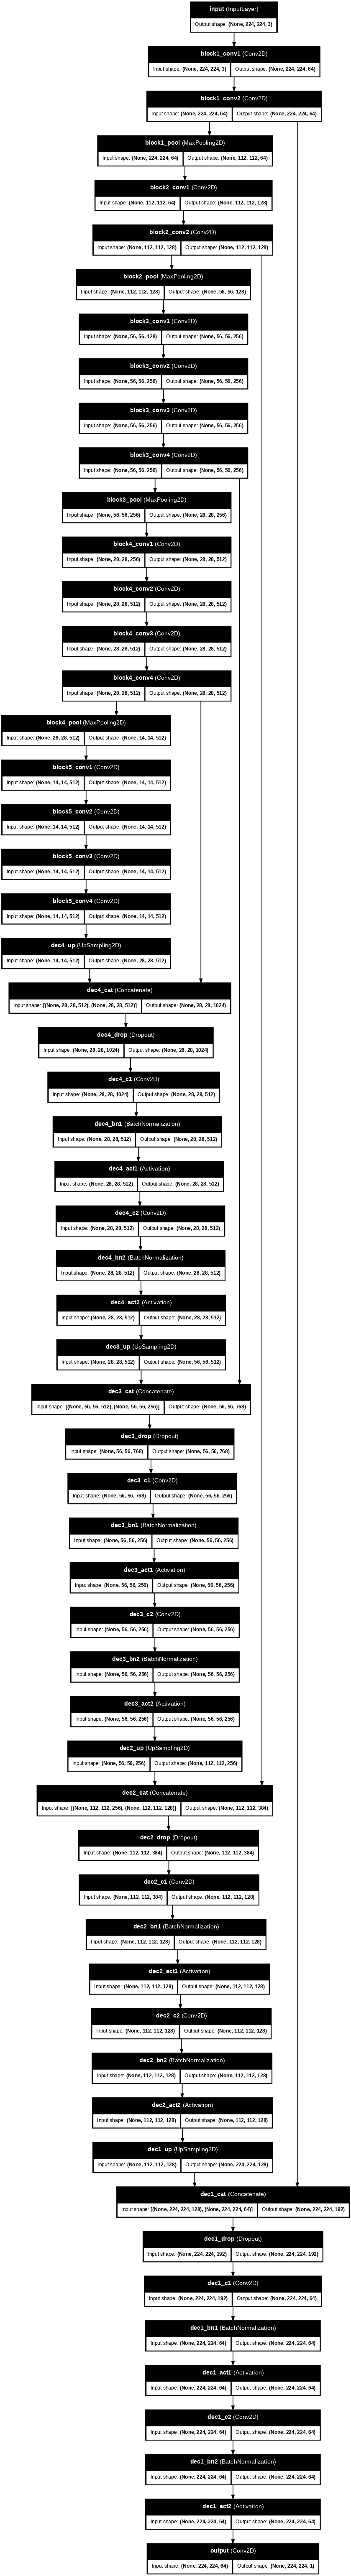

In [11]:
model.summary()

tf.keras.utils.plot_model(
    model,
    to_file='vgg19_unet_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=64
)

## 10. Callbacks  (EarlyStopping disabled — full epochs as instructed)

In [12]:
def create_mask(pred):
    return tf.math.round(pred)


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            pred_mask = create_mask(preds[i])
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(masks[i].numpy()[..., 0], cmap='gray'); axes[1].set_title('Ground Truth')
            axes[2].imshow(pred_mask.numpy()[..., 0], cmap='gray'); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg19unet.keras', verbose=1, save_best_only=True,
                               monitor='val_iou_score', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed — train for the full EPOCHS as instructed
]

print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1781785204.859586     114 service.cc:152] XLA service 0x7a5540001f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781785204.859628     114 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781785205.183537     114 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781785219.235612     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


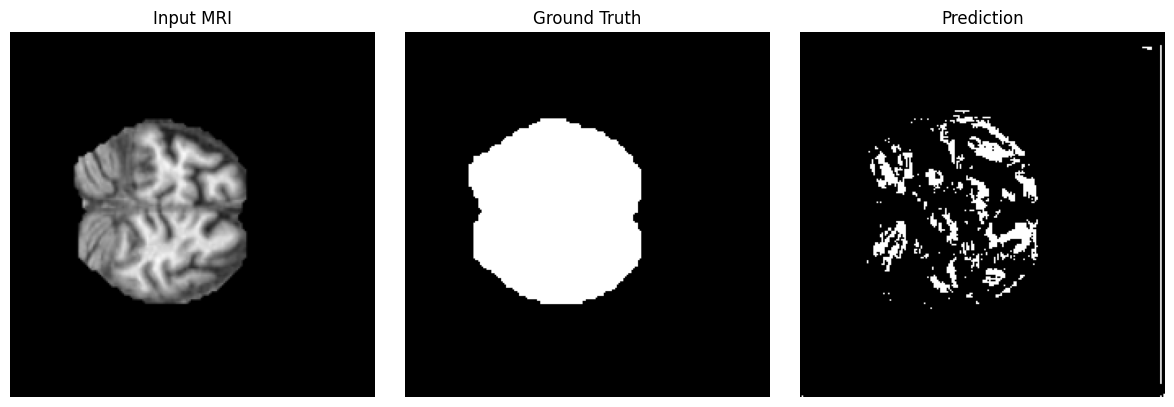

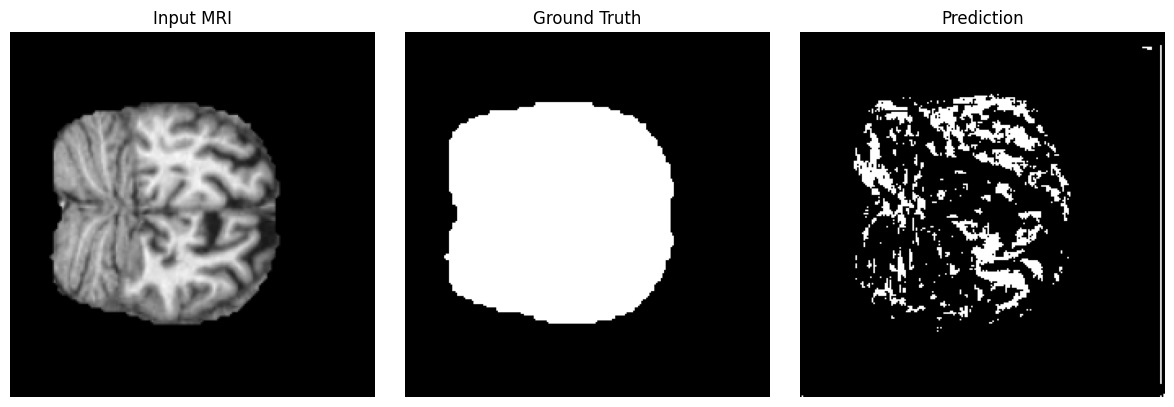

In [13]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 351
Validation steps : 62
Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coefficient: 0.8455 - iou_score: 0.7632 - loss: 0.2647 - pixel_accuracy: 0.9714 - precision_smooth: 0.8041 - recall_smooth: 0.9213
Epoch 1: val_iou_score improved from None to 0.95500, saving model to best_model_vgg19unet.keras

Epoch 1: finished saving model to best_model_vgg19unet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 132s 297ms/step - dice_coefficient: 0.9081 - iou_score: 0.8485 - loss: 0.1448 - pixel_accuracy: 0.9906 - precision_smooth: 0.8685 - recall_smooth: 0.9710 - val_dice_coefficient: 0.9770 - val_iou_score: 0.9550 - val_loss: 0.0396 - val_pixel_accuracy: 0.9973 - val_precision_smooth: 0.9657 - val_recall_smooth: 0.9885 - learning_rate: 1.0000e-04
Epoch 2/100


2026-06-18 12:22:41.449942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 12:22:41.697835: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/351 ━━━━━━━━━━━━━━━━━━━━ 2:38:30 27s/step - dice_coefficient: 0.8552 - iou_score: 0.7471 - loss: 0.1884 - pixel_accuracy: 0.9980 - precision_smooth: 0.7506 - recall_smooth: 0.9939
Epoch 2: val_iou_score did not improve from 0.95500
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - dice_coefficient: 0.8552 - iou_score: 0.7471 - loss: 0.1884 - pixel_accuracy: 0.9980 - precision_smooth: 0.7506 - recall_smooth: 0.9939 - val_dice_coefficient: 0.9766 - val_iou_score: 0.9544 - val_loss: 0.0402 - val_pixel_accuracy: 0.9973 - val_precision_smooth: 0.9652 - val_recall_smooth: 0.9883 - learning_rate: 1.0000e-04
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coefficient: 0.9609 - iou_score: 0.9278 - loss: 0.0577 - pixel_accuracy: 0.9975 - precision_smooth: 0.9369 - recall_smooth: 0.9901
Epoch 3: val_iou_score improved from 0.95500 to 0.98015, saving model to best_model_vgg19unet.keras

Epoch 3: finished saving model to best_model_vgg19unet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 292m

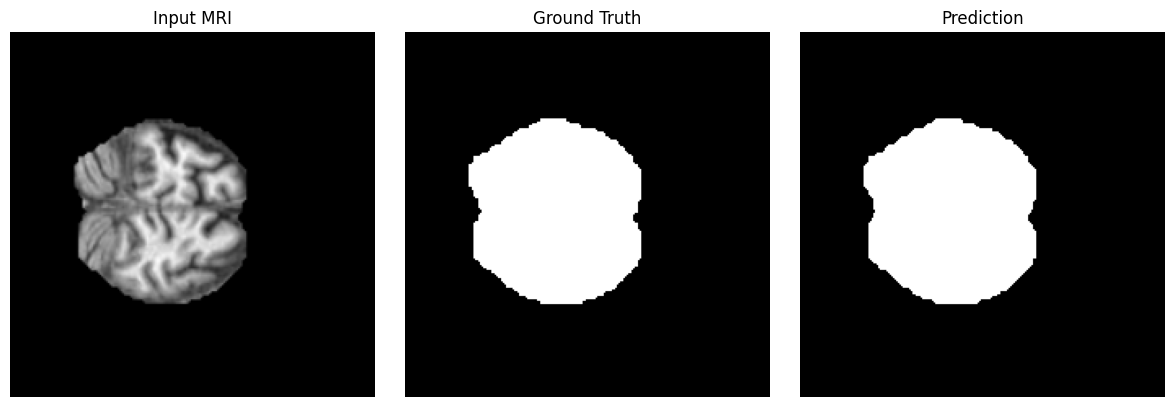

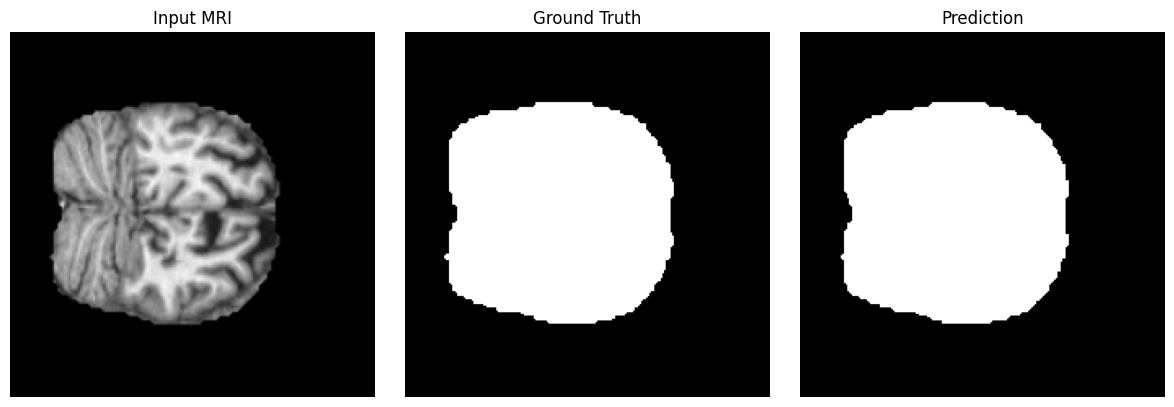

Prediction after epoch 10


Epoch 10: val_iou_score did not improve from 0.98983
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - dice_coefficient: 0.9729 - iou_score: 0.9472 - loss: 0.0351 - pixel_accuracy: 0.9989 - precision_smooth: 0.9532 - recall_smooth: 0.9934 - val_dice_coefficient: 0.9949 - val_iou_score: 0.9898 - val_loss: 0.0097 - val_pixel_accuracy: 0.9987 - val_precision_smooth: 0.9932 - val_recall_smooth: 0.9965 - learning_rate: 1.0000e-04
Epoch 11/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coefficient: 0.9907 - iou_score: 0.9817 - loss: 0.0150 - pixel_accuracy: 0.9986 - precision_smooth: 0.9859 - recall_smooth: 0.9956
Epoch 11: val_iou_score improved from 0.98983 to 0.99223, saving model to best_model_vgg19unet.keras

Epoch 11: finished saving model to best_model_vgg19unet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 292ms/step - dice_coefficient: 0.9910 - iou_score: 0.9822 - loss: 0.0146 - pixel_accuracy: 0.9986 - precision_smooth: 0.9864 - recall_smooth: 0.9957 - val_d

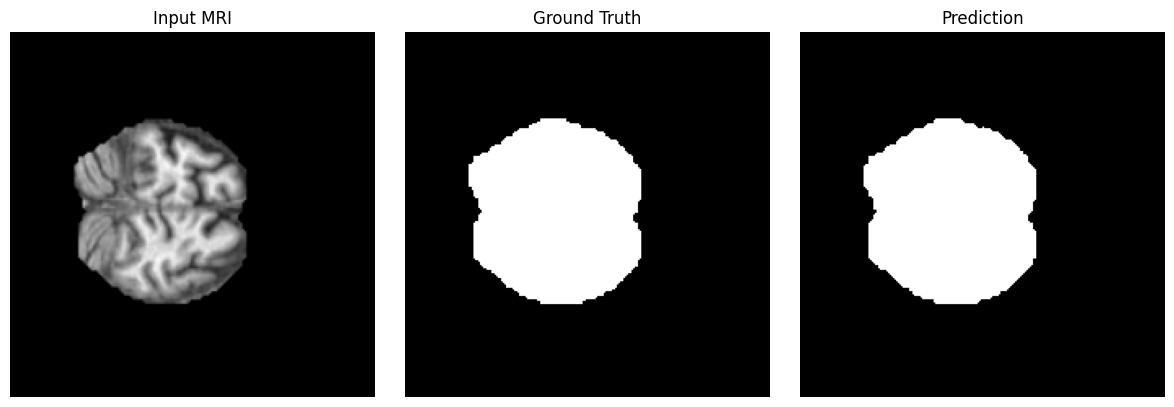

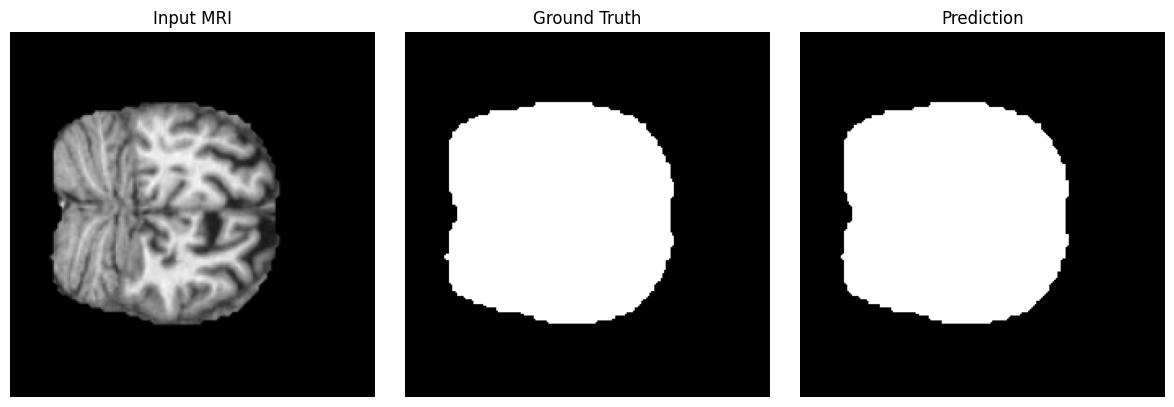

Prediction after epoch 20


Epoch 20: val_iou_score improved from 0.99564 to 0.99564, saving model to best_model_vgg19unet.keras

Epoch 20: finished saving model to best_model_vgg19unet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - dice_coefficient: 0.9897 - iou_score: 0.9796 - loss: 0.0140 - pixel_accuracy: 0.9991 - precision_smooth: 0.9843 - recall_smooth: 0.9951 - val_dice_coefficient: 0.9978 - val_iou_score: 0.9956 - val_loss: 0.0046 - val_pixel_accuracy: 0.9991 - val_precision_smooth: 0.9975 - val_recall_smooth: 0.9981 - learning_rate: 1.0000e-04
Epoch 21/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coefficient: 0.9960 - iou_score: 0.9920 - loss: 0.0072 - pixel_accuracy: 0.9990 - precision_smooth: 0.9946 - recall_smooth: 0.9973
Epoch 21: val_iou_score improved from 0.99564 to 0.99568, saving model to best_model_vgg19unet.keras

Epoch 21: finished saving model to best_model_vgg19unet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 292ms/step - dice_coefficient: 0.9960 - iou_s

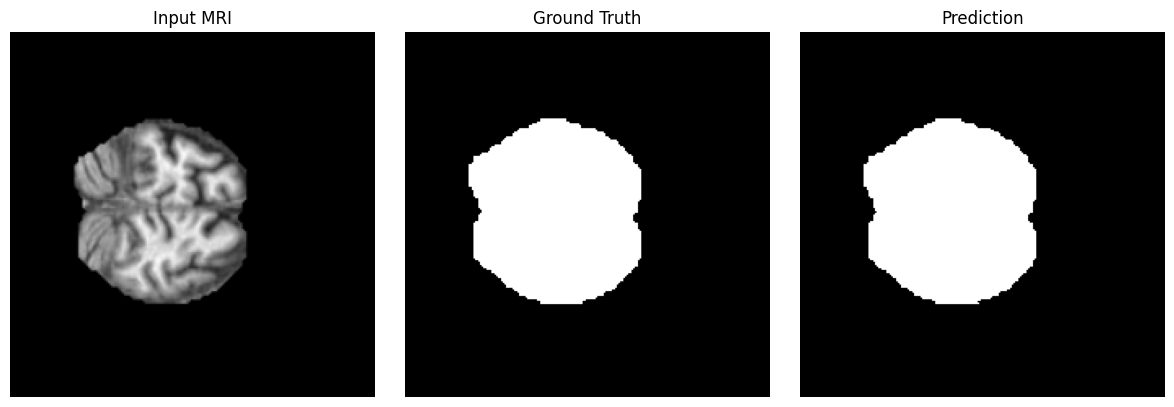

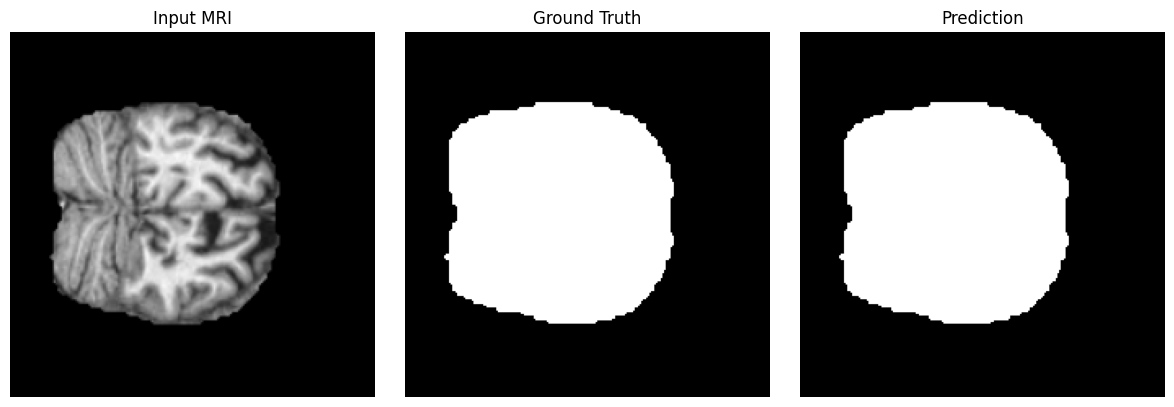

Prediction after epoch 40


Epoch 40: val_iou_score did not improve from 0.99952
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - dice_coefficient: 0.9986 - iou_score: 0.9971 - loss: 0.0019 - pixel_accuracy: 0.9999 - precision_smooth: 0.9978 - recall_smooth: 0.9994 - val_dice_coefficient: 0.9997 - val_iou_score: 0.9995 - val_loss: 4.8575e-04 - val_pixel_accuracy: 0.9999 - val_precision_smooth: 0.9996 - val_recall_smooth: 0.9999 - learning_rate: 1.0000e-04
Epoch 41/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coefficient: 0.9993 - iou_score: 0.9987 - loss: 0.0012 - pixel_accuracy: 0.9998 - precision_smooth: 0.9992 - recall_smooth: 0.9995
Epoch 41: val_iou_score improved from 0.99952 to 0.99968, saving model to best_model_vgg19unet.keras

Epoch 41: finished saving model to best_model_vgg19unet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 291ms/step - dice_coefficient: 0.9993 - iou_score: 0.9987 - loss: 0.0013 - pixel_accuracy: 0.9998 - precision_smooth: 0.9992 - recall_smooth: 0.9995 - v

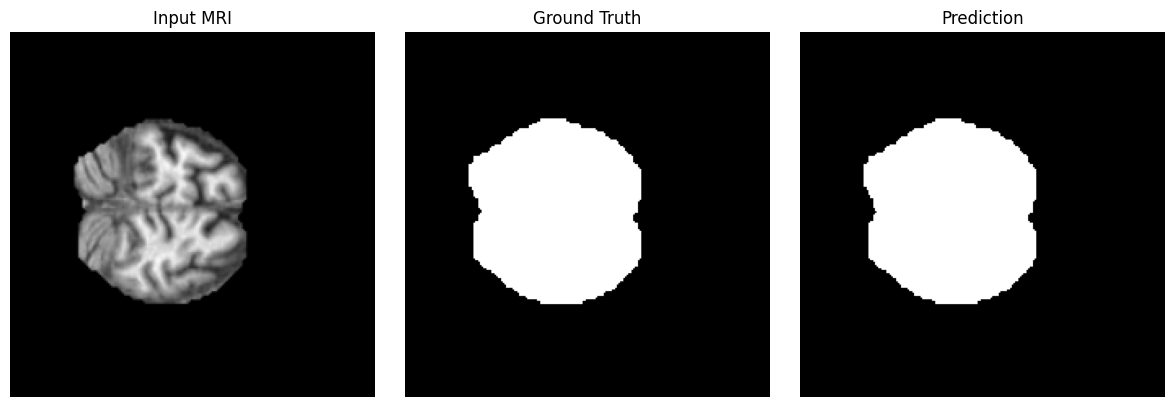

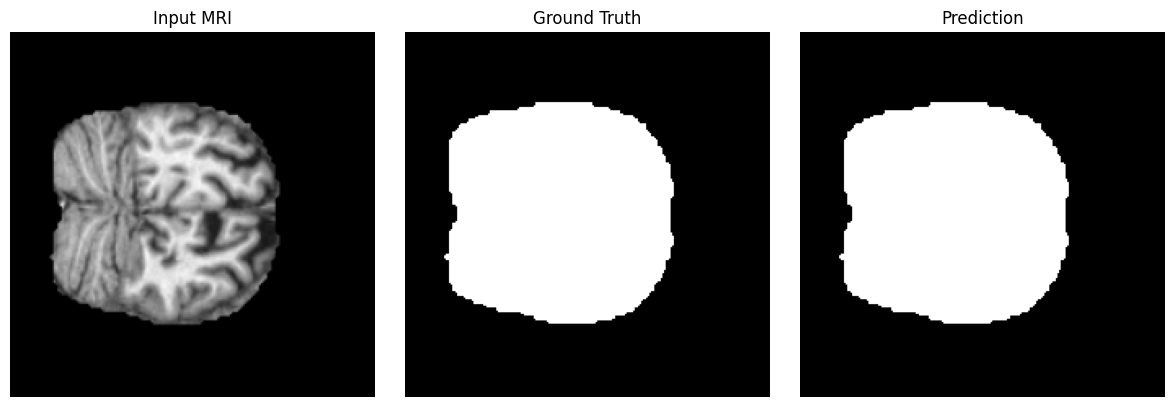

Prediction after epoch 50


Epoch 50: val_iou_score did not improve from 0.99981
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - dice_coefficient: 0.9993 - iou_score: 0.9986 - loss: 9.2028e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9990 - recall_smooth: 0.9996 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 2.1004e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9998 - val_recall_smooth: 1.0000 - learning_rate: 5.0000e-05
Epoch 51/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coefficient: 0.9996 - iou_score: 0.9993 - loss: 7.0706e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9996 - recall_smooth: 0.9997
Epoch 51: val_iou_score improved from 0.99981 to 0.99984, saving model to best_model_vgg19unet.keras

Epoch 51: finished saving model to best_model_vgg19unet.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 292ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 7.5497e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9996 - recall_smooth

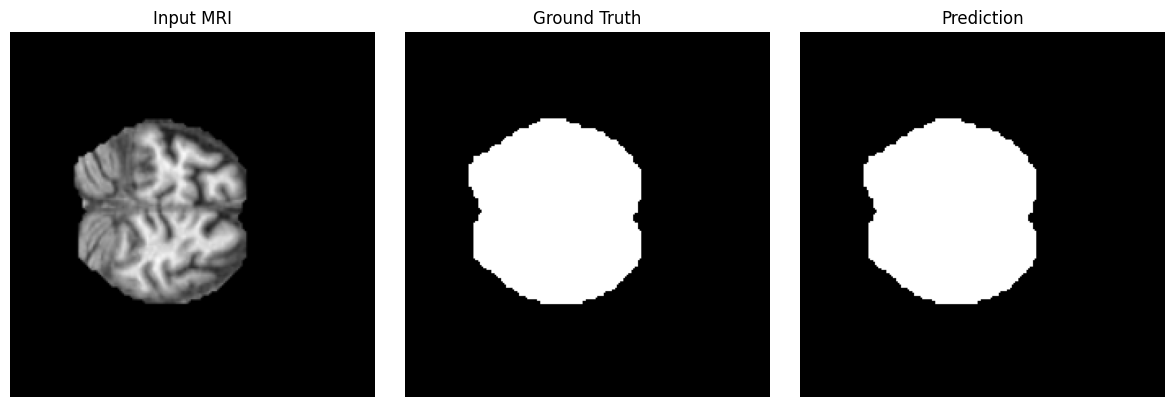

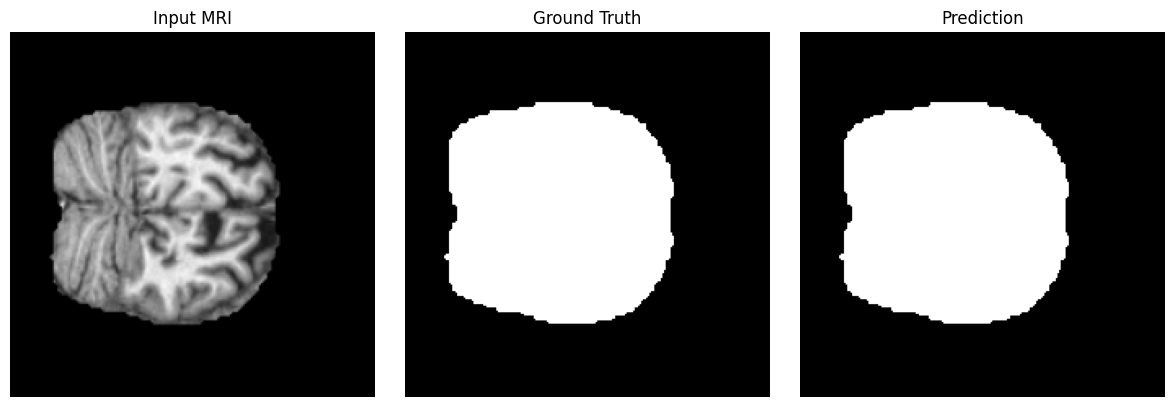

Prediction after epoch 60


Epoch 60: val_iou_score did not improve from 0.99984
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - dice_coefficient: 0.9993 - iou_score: 0.9985 - loss: 0.0011 - pixel_accuracy: 0.9999 - precision_smooth: 0.9993 - recall_smooth: 0.9992 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.9702e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9998 - val_recall_smooth: 1.0000 - learning_rate: 1.2500e-05
Epoch 61/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - dice_coefficient: 0.9997 - iou_score: 0.9995 - loss: 5.4749e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998
Epoch 61: val_iou_score did not improve from 0.99984
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 289ms/step - dice_coefficient: 0.9997 - iou_score: 0.9994 - loss: 5.7064e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 2.2680e-04 - val_pixel_accuracy: 1.0000

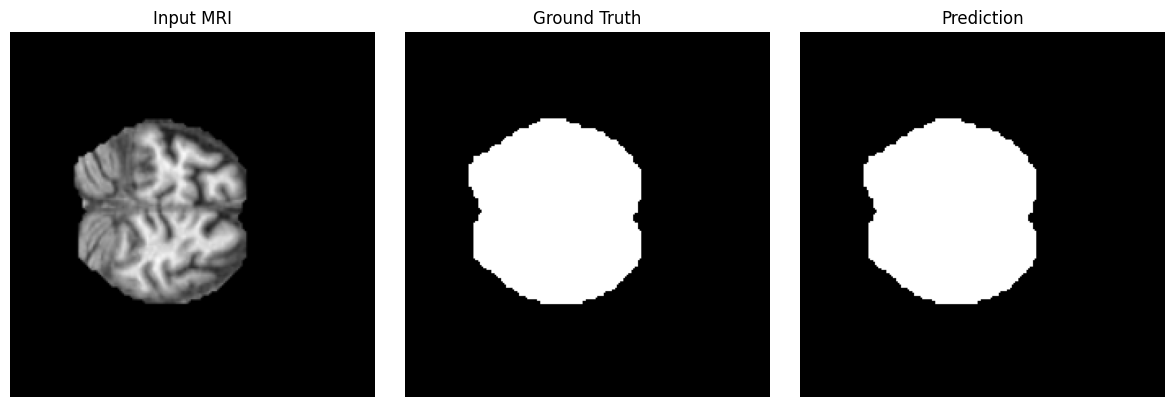

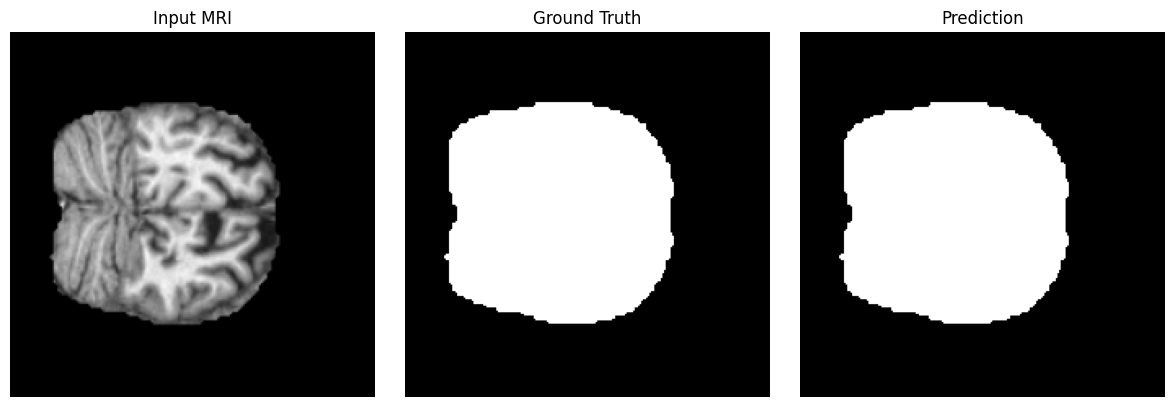

Prediction after epoch 70


Epoch 70: val_iou_score did not improve from 0.99985
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - dice_coefficient: 0.9996 - iou_score: 0.9991 - loss: 5.8242e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.5017e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9999 - val_recall_smooth: 1.0000 - learning_rate: 3.1250e-06
Epoch 71/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - dice_coefficient: 0.9997 - iou_score: 0.9995 - loss: 5.0572e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998
Epoch 71: val_iou_score did not improve from 0.99985
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 288ms/step - dice_coefficient: 0.9997 - iou_score: 0.9995 - loss: 5.4208e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.5848e-04 - val_pixel_accuracy: 1.

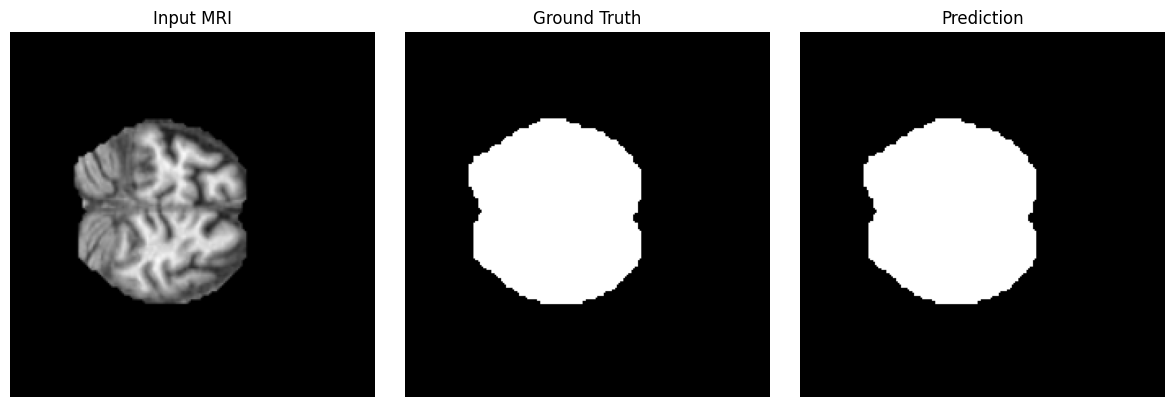

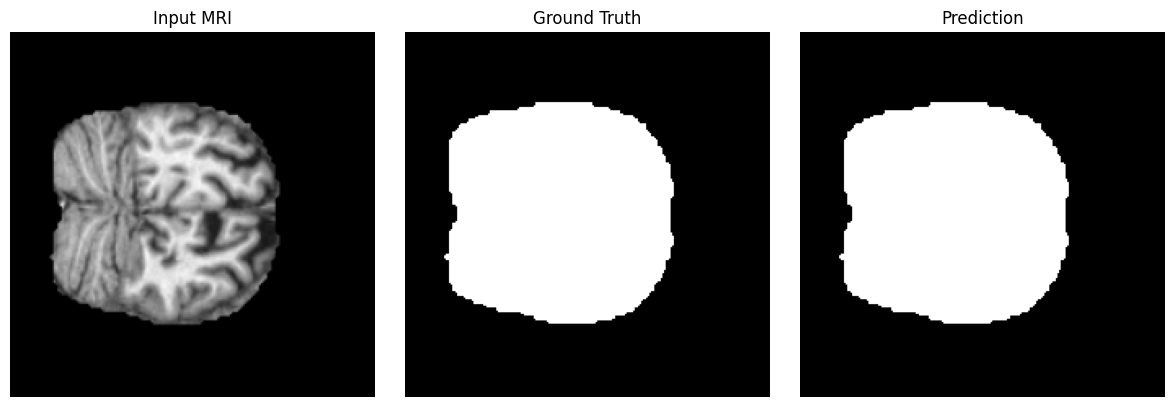

Prediction after epoch 80


Epoch 80: val_iou_score did not improve from 0.99985
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - dice_coefficient: 0.9996 - iou_score: 0.9993 - loss: 4.8877e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9999 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.4789e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9999 - val_recall_smooth: 1.0000 - learning_rate: 7.8125e-07
Epoch 81/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - dice_coefficient: 0.9998 - iou_score: 0.9995 - loss: 4.7844e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998
Epoch 81: val_iou_score did not improve from 0.99985
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 289ms/step - dice_coefficient: 0.9997 - iou_score: 0.9995 - loss: 5.1318e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.4742e-04 - val_pixel_accuracy: 1.

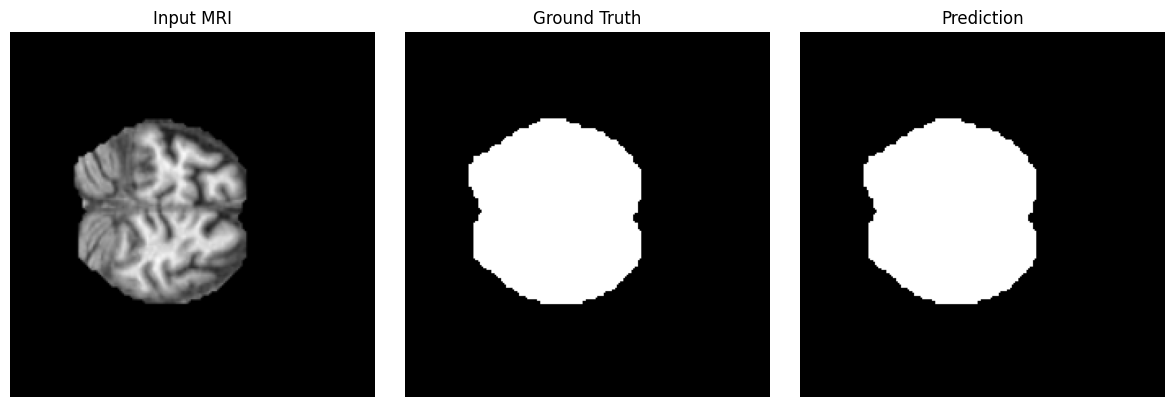

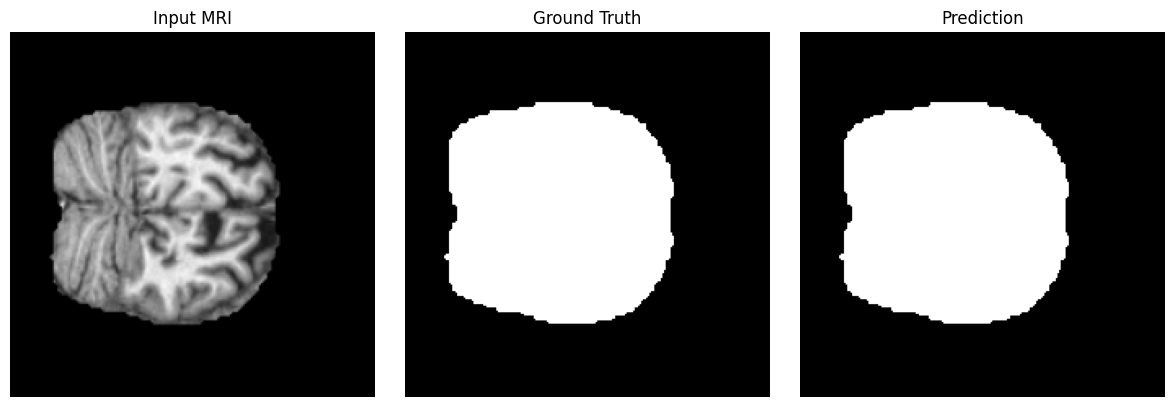

Prediction after epoch 90


Epoch 90: val_iou_score did not improve from 0.99985
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.5308e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.4565e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9999 - val_recall_smooth: 1.0000 - learning_rate: 1.9531e-07
Epoch 91/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - dice_coefficient: 0.9998 - iou_score: 0.9995 - loss: 4.8394e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998
Epoch 91: val_iou_score did not improve from 0.99985
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 289ms/step - dice_coefficient: 0.9997 - iou_score: 0.9995 - loss: 5.2840e-04 - pixel_accuracy: 0.9999 - precision_smooth: 0.9997 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.4559e-04 - val_pixel_accuracy: 1.

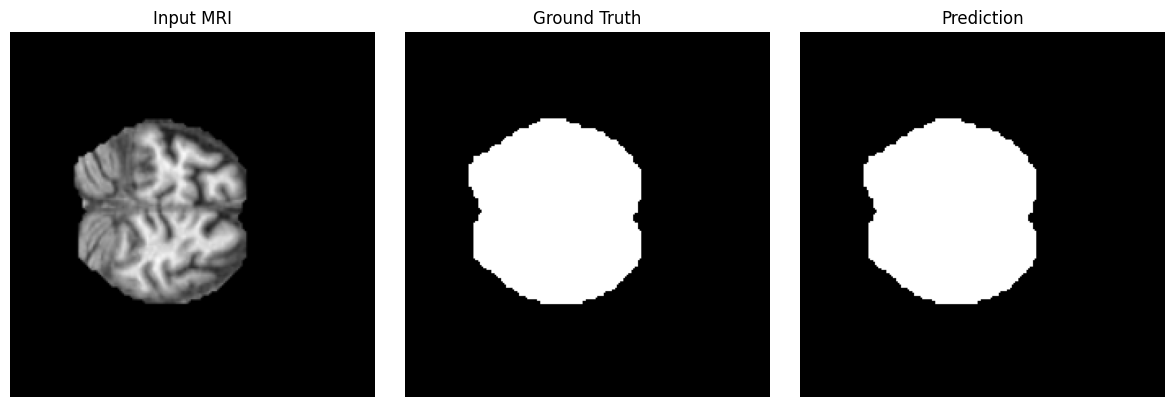

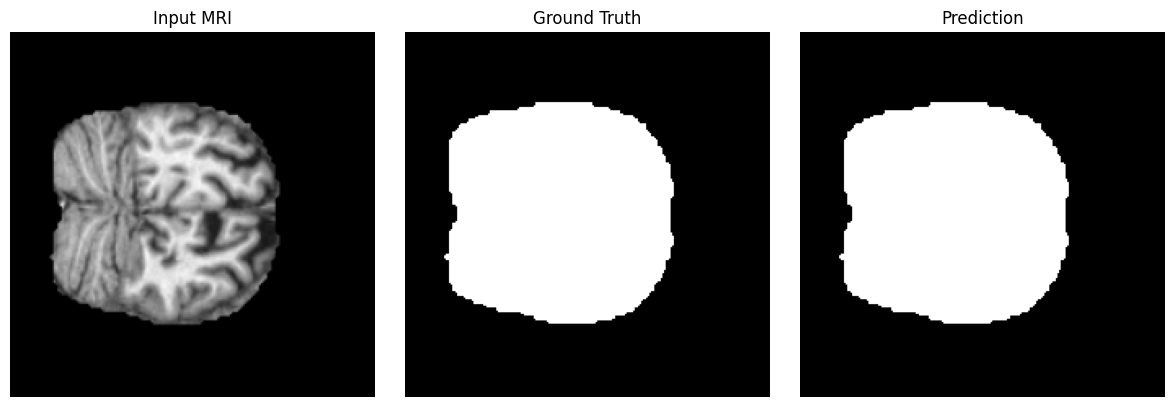

Prediction after epoch 100


Epoch 100: val_iou_score did not improve from 0.99985
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - dice_coefficient: 0.9995 - iou_score: 0.9990 - loss: 7.1168e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9992 - recall_smooth: 0.9998 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.4394e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9999 - val_recall_smooth: 1.0000 - learning_rate: 1.0000e-07

Training time: 96.1 min


In [14]:
steps_per_epoch  = len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE
validation_steps = len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

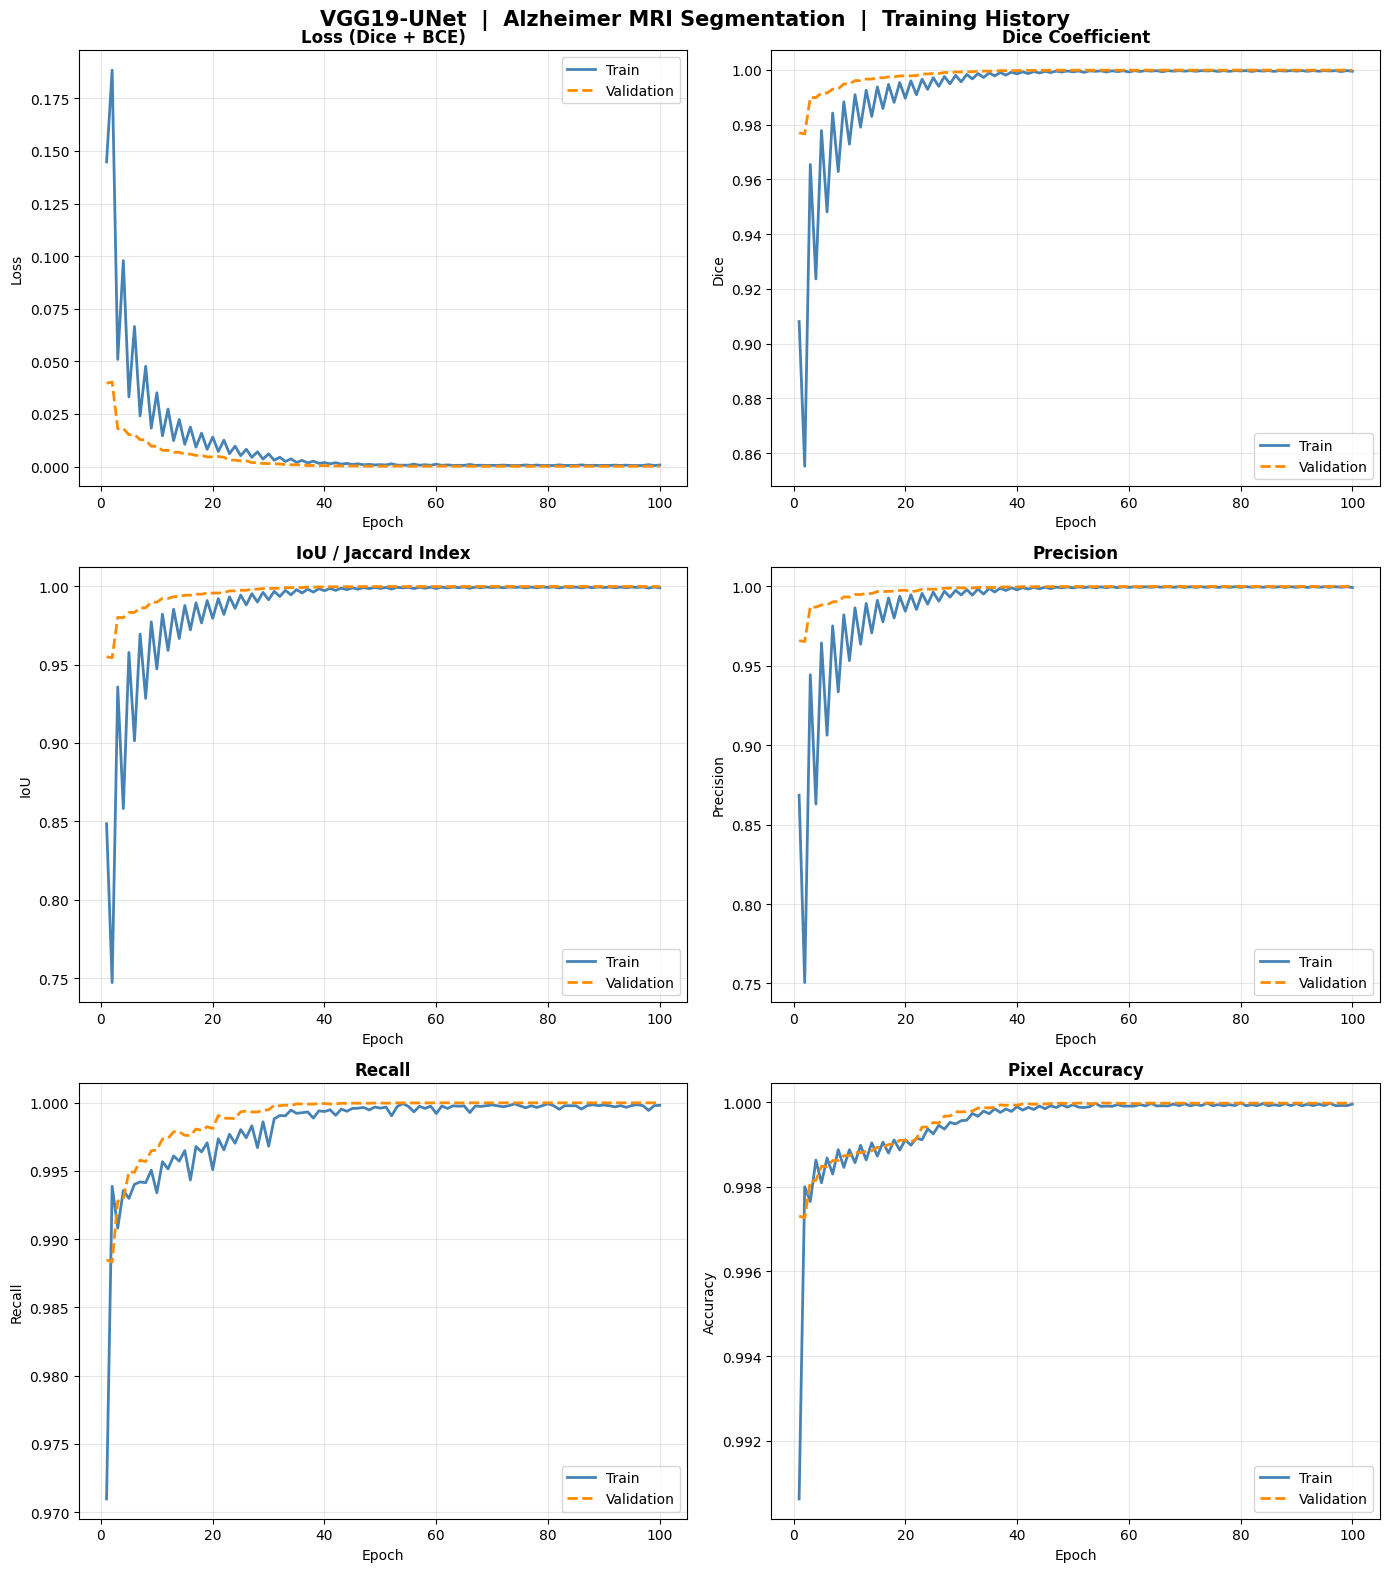

Plot saved → training_history_vgg19unet.png


In [15]:
H = history.history

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('VGG19-UNet  |  Alzheimer MRI Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.98)

plot_specs = [
    ('loss',             'val_loss',             'Loss (Dice + BCE)',      'Loss',     'upper right'),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',       'Dice',     'lower right'),
    ('iou_score',        'val_iou_score',        'IoU / Jaccard Index',    'IoU',      'lower right'),
    ('precision_smooth', 'val_precision_smooth', 'Precision',              'Precision','lower right'),
    ('recall_smooth',    'val_recall_smooth',    'Recall',                 'Recall',   'lower right'),
    ('pixel_accuracy',   'val_pixel_accuracy',   'Pixel Accuracy',         'Accuracy', 'lower right'),
]

for ax, (train_key, val_key, title, ylabel, loc) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train',      color='steelblue',   linewidth=2)
    ax.plot(epochs_range, H[val_key],   label='Validation', color='darkorange',  linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(loc=loc, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_vgg19unet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → training_history_vgg19unet.png')

## 14. Best & Average Metrics Table

In [16]:
metric_spec = [
    ('Loss',           'loss',             'min'),
    ('Dice',           'dice_coefficient', 'max'),
    ('IoU (Jaccard)',  'iou_score',        'max'),
    ('Precision',      'precision_smooth', 'max'),
    ('Recall',         'recall_smooth',    'max'),
    ('Pixel Accuracy', 'pixel_accuracy',   'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key],          dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({
        'Metric':     disp,
        'Train Best': pick(tr), 'Train Avg': tr.mean(),
        'Val Best':   pick(va), 'Val Avg':   va.mean(),
    })

def f1_curve(p, r):
    p = np.asarray(p, dtype=np.float64); r = np.asarray(r, dtype=np.float64)
    return 2.0 * p * r / (p + r + 1e-7)

tr_f1 = f1_curve(H['precision_smooth'],     H['recall_smooth'])
va_f1 = f1_curve(H['val_precision_smooth'], H['val_recall_smooth'])
rows.append({'Metric': 'F1-Score',
             'Train Best': tr_f1.max(), 'Train Avg': tr_f1.mean(),
             'Val Best':   va_f1.max(), 'Val Avg':   va_f1.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG19-UNet  |  OASIS disc1+disc2')
print('=' * 68)
print(report.to_string())
print('=' * 68)

best_epoch_iou  = int(np.argmax(H['val_iou_score']))  + 1
best_epoch_dice = int(np.argmax(H['val_dice_coefficient'])) + 1
print(f'\nBest Val IoU : {max(H["val_iou_score"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val Dice: {max(H["val_dice_coefficient"]):.4f}  (epoch {best_epoch_dice})')

# Overfitting check — gap between train and val at final epoch
final_gap_iou  = H['val_iou_score'][-1]  - H['iou_score'][-1]
final_gap_dice = H['val_dice_coefficient'][-1] - H['dice_coefficient'][-1]
print(f'\nFinal-epoch Val-Train gap → IoU: {final_gap_iou:+.4f}, Dice: {final_gap_dice:+.4f}')
print('(Large positive gap can indicate train metrics still catching up;')
print(' large negative gap with val dropping while train keeps rising = overfitting.)')

report

   BEST & AVERAGE METRICS  —  VGG19-UNet  |  OASIS disc1+disc2
                Train Best  Train Avg  Val Best  Val Avg
Metric                                                  
Loss                0.0005     0.0100    0.0001   0.0030
Dice                0.9998     0.9929    0.9999   0.9984
IoU (Jaccard)       0.9995     0.9868    0.9998   0.9968
Precision           0.9997     0.9884    0.9999   0.9978
Recall              0.9999     0.9982    1.0000   0.9990
Pixel Accuracy      1.0000     0.9995    1.0000   0.9996
F1-Score            0.9998     0.9930    0.9999   0.9984

Best Val IoU : 0.9998  (epoch 99)
Best Val Dice: 0.9999  (epoch 99)

Final-epoch Val-Train gap → IoU: +0.0008, Dice: +0.0004
(Large positive gap can indicate train metrics still catching up;
 large negative gap with val dropping while train keeps rising = overfitting.)


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.0005,0.0100,0.0001,0.0030
Dice,0.9998,0.9929,0.9999,0.9984
IoU (Jaccard),0.9995,0.9868,0.9998,0.9968
Precision,0.9997,0.9884,0.9999,0.9978
Recall,0.9999,0.9982,1.0000,0.9990
Pixel Accuracy,1.0000,0.9995,1.0000,0.9996
F1-Score,0.9998,0.9930,0.9999,0.9984


## 15. Load Best Model & Final Evaluation

In [17]:
best_model = tf.keras.models.load_model(
    'best_model_vgg19unet.keras',
    custom_objects={
        'combined_loss':   combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score':        iou_score,
        'precision_smooth': precision_smooth,
        'recall_smooth':    recall_smooth,
        'pixel_accuracy':   pixel_accuracy,
    }
)
print('Best model loaded ✓')
best_model.summary()

Best model loaded ✓


Model: "VGG19_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 28, 28,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv4[0][

 Total params: 50,569,093 (192.91 MB)

 Trainable params: 10,180,289 (38.83 MB)

 Non-trainable params: 20,028,224 (76.40 MB)

 Optimizer params: 20,360,580 (77.67 MB)

In [18]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict    = dict(zip(best_model.metrics_names, test_results))

label_map = {
    'loss': 'Loss', 'dice_coefficient': 'Dice', 'iou_score': 'IoU (Jaccard)',
    'precision_smooth': 'Precision', 'recall_smooth': 'Recall', 'pixel_accuracy': 'Pixel Accuracy'
}

P = test_dict.get('precision_smooth', 0)
R = test_dict.get('recall_smooth',    0)
f1 = 2 * P * R / (P + R + 1e-7)

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG19-UNet | OASIS disc1+disc2)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {label_map.get(k, k):20s}: {v:.4f}')
print(f'  {"F1-Score":20s}: {f1:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model':      'VGG19-UNet (OASIS disc1+disc2)',
    'IoU':        round(test_dict.get('iou_score', float('nan')), 4),
    'Dice':       round(test_dict.get('dice_coefficient', float('nan')), 4),
    'Precision':  round(P, 4),
    'Recall':     round(R, 4),
    'Accuracy':   round(test_dict.get('pixel_accuracy', float('nan')), 4),
    'F1':         round(f1, 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coefficient: 0.9999 - iou_score: 0.9999 - loss: 1.3562e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9999 - recall_smooth: 1.0000

2026-06-18 13:56:43.307184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 13:56:43.550902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - dice_coefficient: 0.9999 - iou_score: 0.9998 - loss: 1.4315e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9999 - recall_smooth: 1.0000

  FINAL TEST-SET METRICS  (VGG19-UNet | OASIS disc1+disc2)
  Loss                : 0.0001
  compile_metrics     : 0.9999
  F1-Score            : 0.0000


,IoU,Dice,Precision,Recall,Accuracy,F1
Model,,,,,,
VGG19-UNet (OASIS disc1+disc2),NaN,NaN,0,0,NaN,0.0


## 16. Test Predictions Visualization

Test set predictions:


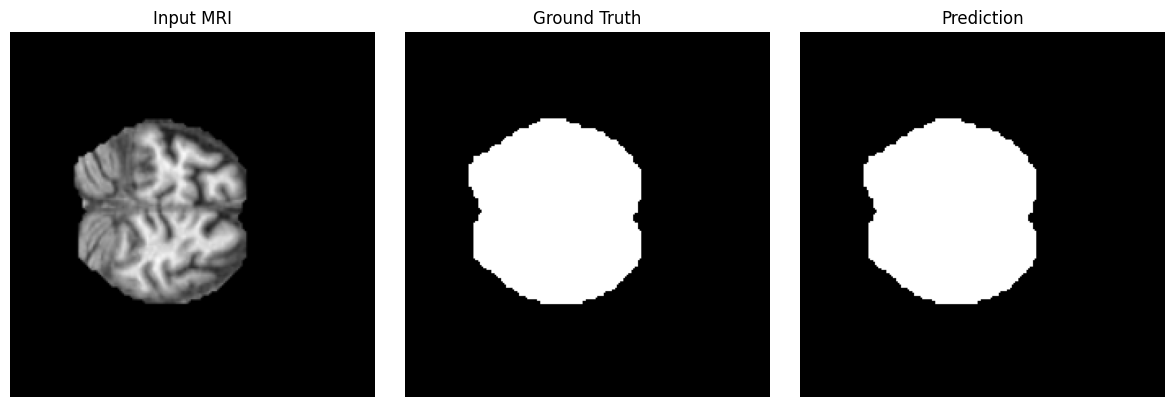

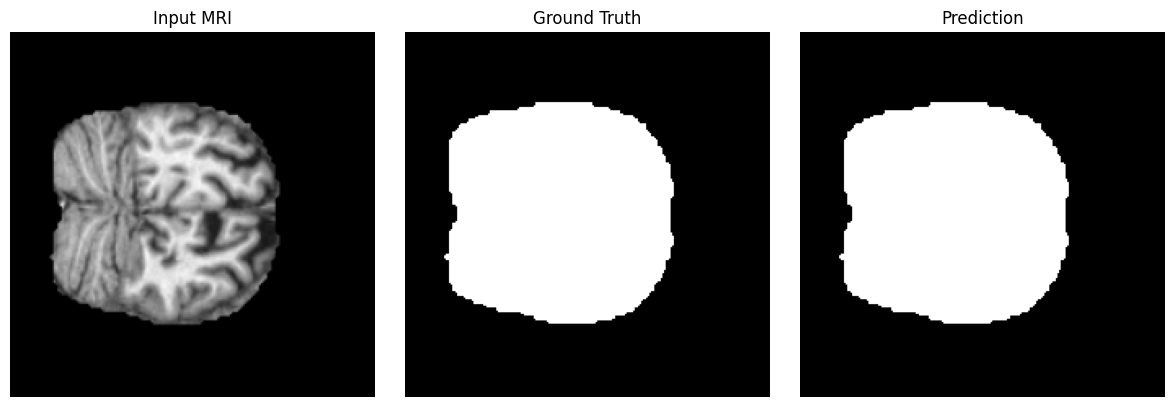

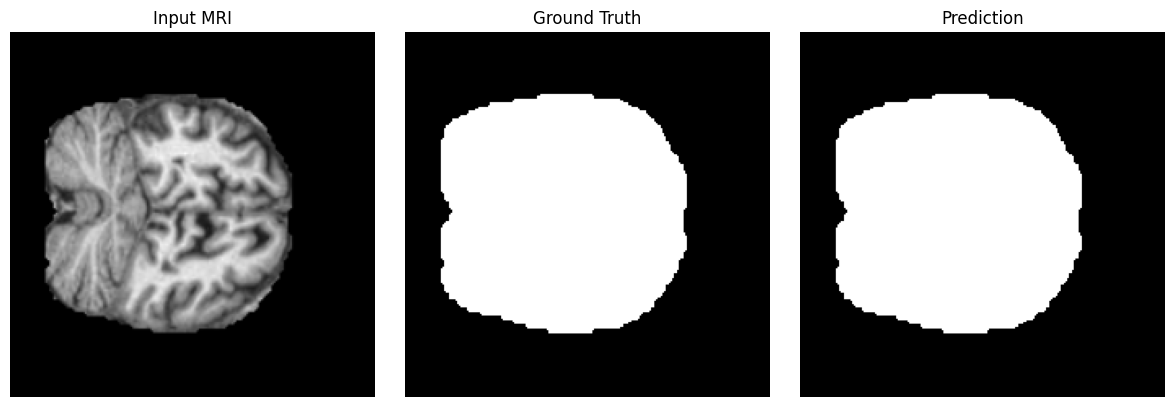

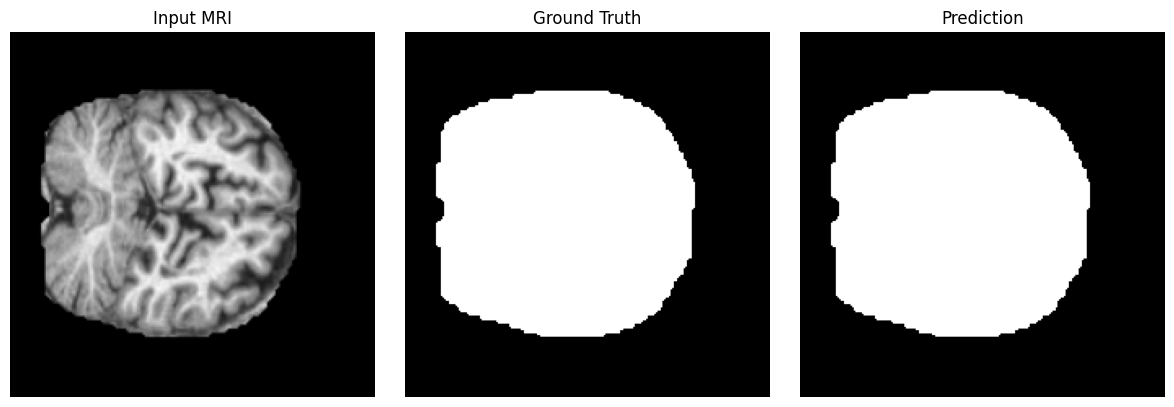

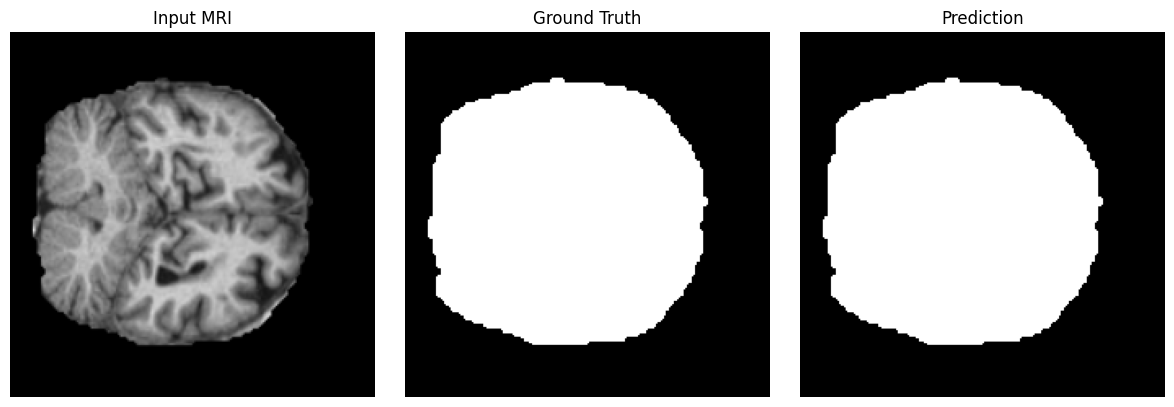

In [19]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Detailed Prediction Grid

2026-06-18 13:56:52.380388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 13:56:52.625452: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


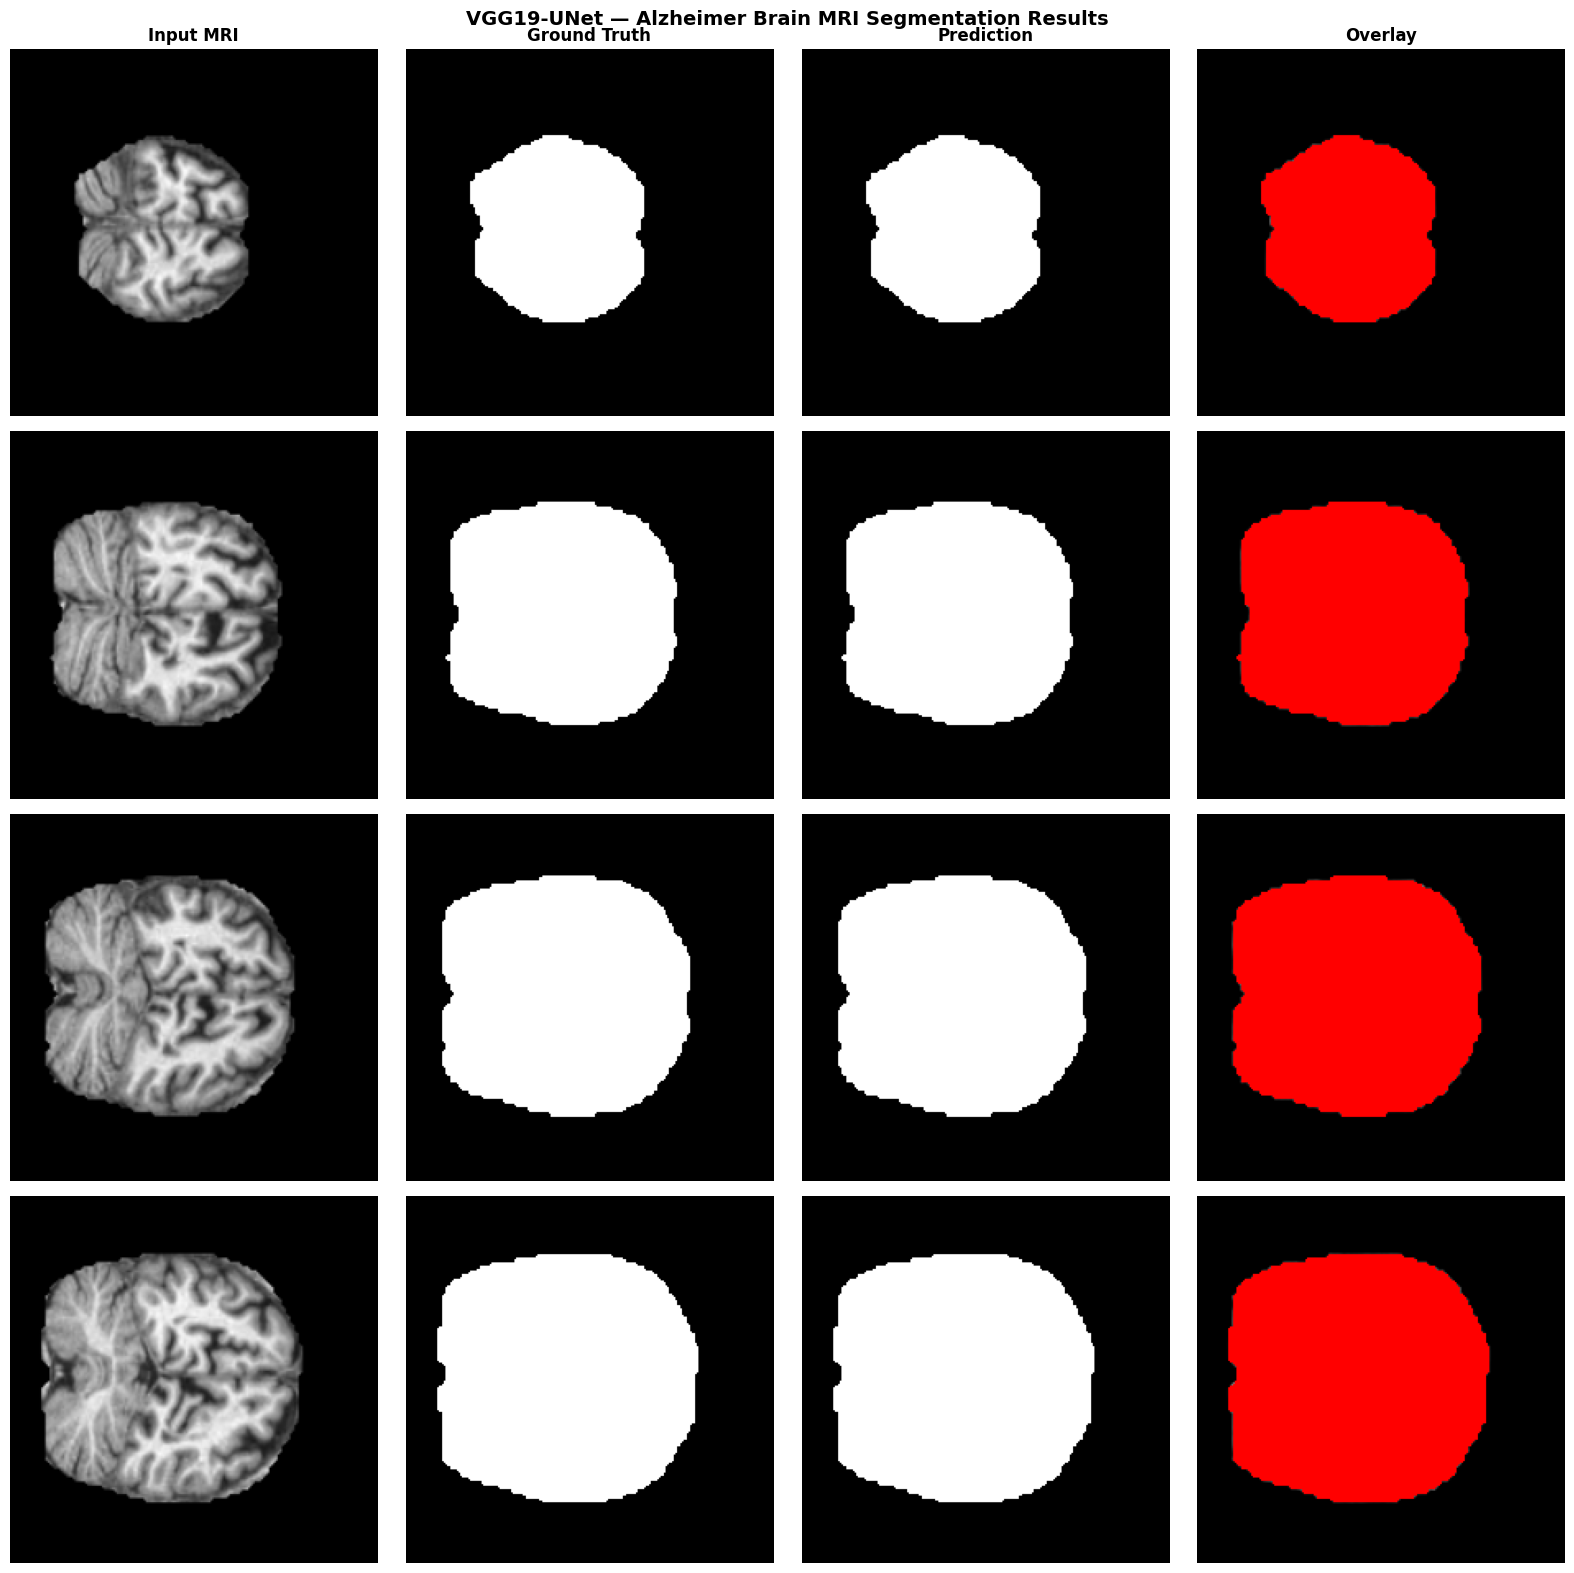

Grid saved → prediction_grid_vgg19unet.png


In [20]:
def prediction_grid(dataset, best_model, n_rows=4):
    for imgs, masks in dataset.take(1):
        preds = best_model.predict(imgs[:n_rows], verbose=0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
        col_titles = ['Input MRI', 'Ground Truth', 'Prediction', 'Overlay']
        for col, t in enumerate(col_titles):
            axes[0, col].set_title(t, fontsize=12, fontweight='bold')

        for row in range(n_rows):
            img   = imgs[row].numpy()
            gt    = masks[row].numpy()[..., 0]
            pred  = create_mask(preds[row]).numpy()[..., 0]

            ov = (img * 255).astype(np.uint8)
            ov[pred > 0.5, 0] = 255
            ov[pred > 0.5, 1] = 0
            ov[pred > 0.5, 2] = 0

            inter = np.sum(gt * pred)
            union = np.sum(gt) + np.sum(pred) - inter
            sample_iou = (inter + 1) / (union + 1)

            axes[row, 0].imshow(img)
            axes[row, 1].imshow(gt,   cmap='gray')
            axes[row, 2].imshow(pred, cmap='gray')
            axes[row, 2].set_xlabel(f'IoU: {sample_iou:.3f}', fontsize=10, color='green')
            axes[row, 3].imshow(ov)

            for col in range(4):
                axes[row, col].axis('off')

        plt.suptitle('VGG19-UNet — Alzheimer Brain MRI Segmentation Results',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('prediction_grid_vgg19unet.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Grid saved → prediction_grid_vgg19unet.png')


prediction_grid(test_dataset, best_model, n_rows=4)

## 18. IoU Distribution Plot

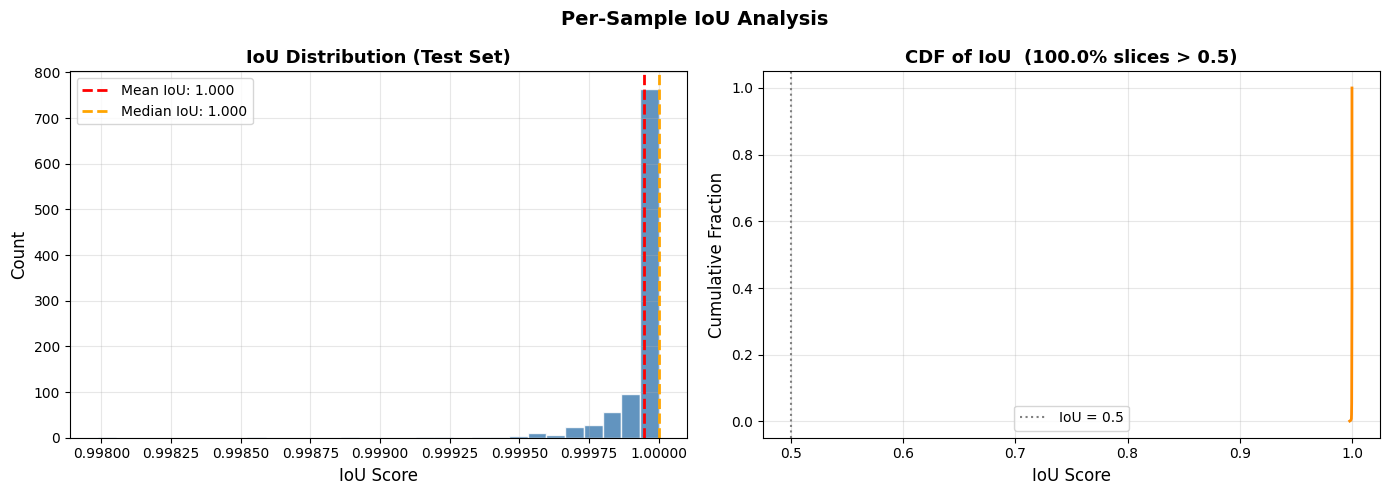


IoU Stats — Mean: 0.9999  |  Std: 0.0001
             Min : 0.9980  |  Max: 1.0000
% slices IoU > 0.5 : 100.0%


In [21]:
iou_scores = []

for imgs, masks in test_dataset:
    preds = best_model.predict(imgs, verbose=0)
    for i in range(len(imgs)):
        gt   = masks[i].numpy()[..., 0]
        pred = (preds[i][..., 0] > 0.5).astype(float)
        inter = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - inter
        iou_scores.append((inter + 1) / (union + 1))

iou_arr = np.array(iou_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(iou_arr, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(iou_arr.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean IoU: {iou_arr.mean():.3f}')
axes[0].axvline(np.median(iou_arr), color='orange', linestyle='--', linewidth=2,
                label=f'Median IoU: {np.median(iou_arr):.3f}')
axes[0].set_xlabel('IoU Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('IoU Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_iou = np.sort(iou_arr)
cdf = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1].plot(sorted_iou, cdf, color='darkorange', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle=':', label='IoU = 0.5')
pct_above_50 = np.mean(iou_arr > 0.5) * 100
axes[1].set_xlabel('IoU Score', fontsize=12)
axes[1].set_ylabel('Cumulative Fraction', fontsize=12)
axes[1].set_title(f'CDF of IoU  ({pct_above_50:.1f}% slices > 0.5)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Per-Sample IoU Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iou_distribution_vgg19unet.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIoU Stats — Mean: {iou_arr.mean():.4f}  |  Std: {iou_arr.std():.4f}')
print(f'             Min : {iou_arr.min():.4f}  |  Max: {iou_arr.max():.4f}')
print(f'% slices IoU > 0.5 : {pct_above_50:.1f}%')

## 19. Save Final Model

In [22]:
best_model.save('alzheimer_vgg19_unet_final.keras')
print('Model saved → alzheimer_vgg19_unet_final.keras')

Model saved → alzheimer_vgg19_unet_final.keras
